# Tutorial 03a: Pre-trained CNNs, freezing layers, and transfer learning
Prof Ivan Olier

## Introduction

In this tutorial, we practise the ideas introduced at the beginning of Session 03: pre-training, freezing layers, and transfer learning. Instead of training every convolutional layer from scratch, we reuse a CNN that has already learned useful visual features from a large image dataset.

The practical example uses a small binary classification task derived from CIFAR-10. We first train a compact CNN from scratch, then compare it with a transfer-learning model based on a pre-trained MobileNetV2 feature extractor.

The notebook is designed to run on a CPU, although it will run faster on a GPU. To keep the runtime manageable, we use a small subset of the data and a small number of epochs.


We begin with the standard numerical and plotting libraries. The random seeds are fixed to make the results more reproducible across runs.


In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

%matplotlib inline

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


I0000 00:00:1782343153.578967   42738 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782343153.613377   42738 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782343154.476755   42738 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Keras provides both the layers needed to build our own CNN and a collection of pre-trained CNN architectures through `tf.keras.applications`. In this tutorial, we use `MobileNetV2` because it is relatively small and efficient, making it more suitable for a teaching session without guaranteed GPU access.


In [2]:
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


The learning curves will be used throughout the notebook to compare how the scratch model and the transfer-learning model behave during training. Ideally, training and validation curves should improve together without a large gap between them.


In [3]:
def plot_history(history):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'])

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'])

    plt.tight_layout()
    return


A small utility function is also useful for inspecting how many parameters are trainable. This is central to transfer learning: when a layer is frozen, its weights remain in the model but are not updated during training.


In [4]:
def count_params(model):
    trainable = np.sum([np.prod(w.shape) for w in model.trainable_weights])
    non_trainable = np.sum([np.prod(w.shape) for w in model.non_trainable_weights])
    return int(trainable), int(non_trainable)


def print_parameter_summary(model, name='model'):
    trainable, non_trainable = count_params(model)
    print(f'{name} trainable parameters:     {trainable:,}')
    print(f'{name} non-trainable parameters: {non_trainable:,}')
    print(f'{name} total parameters:         {trainable + non_trainable:,}')


## Dataset

CIFAR-10 contains 32 × 32 colour images from 10 object classes. To keep the example simple, we convert it into a binary classification problem using only two classes: cats and dogs.

The images are much smaller than ImageNet images, but the task is sufficient to demonstrate the mechanics of transfer learning: load a pre-trained CNN, freeze its convolutional base, attach a new classifier, and optionally fine-tune some of the deeper layers.


In [5]:
(X_train_all, y_train_all), (X_test_all, y_test_all) = cifar10.load_data()

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print('Full training set:', X_train_all.shape, y_train_all.shape)
print('Full test set:', X_test_all.shape, y_test_all.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 30s 0us/step
Full training set: (50000, 32, 32, 3) (50000, 1)
Full test set: (10000, 32, 32, 3) (10000, 1)


The following function selects a balanced subset from two CIFAR-10 classes. The lower class index is encoded as 0 and the higher one as 1. You can later change the class indices to build a different binary classification task.


In [6]:
def make_binary_subset(X, y, class_0, class_1, n_per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    y = y.reshape(-1)

    idx_0 = np.where(y == class_0)[0]
    idx_1 = np.where(y == class_1)[0]

    rng.shuffle(idx_0)
    rng.shuffle(idx_1)

    idx = np.concatenate([idx_0[:n_per_class], idx_1[:n_per_class]])
    rng.shuffle(idx)

    X_subset = X[idx].astype('float32')
    y_subset = (y[idx] == class_1).astype('float32')

    return X_subset, y_subset


For classroom delivery, the subset size is intentionally modest. Increasing `TRAIN_PER_CLASS` and `TEST_PER_CLASS` will usually improve performance estimates, but it will also increase training time.


In [7]:
CLASS_0 = 3   # cat
CLASS_1 = 5   # dog

TRAIN_PER_CLASS = 1000
TEST_PER_CLASS = 250

X_train, y_train = make_binary_subset(X_train_all, y_train_all, CLASS_0, CLASS_1, TRAIN_PER_CLASS)
X_test, y_test = make_binary_subset(X_test_all, y_test_all, CLASS_0, CLASS_1, TEST_PER_CLASS)

print('Classes:', class_names[CLASS_0], 'vs', class_names[CLASS_1])
print('Training subset:', X_train.shape, y_train.shape)
print('Test subset:', X_test.shape, y_test.shape)
print('Class balance in training subset:', np.bincount(y_train.astype(int)))


Classes: cat vs dog
Training subset: (2000, 32, 32, 3) (2000,)
Test subset: (500, 32, 32, 3) (500,)
Class balance in training subset: [1000 1000]


Before modelling, we inspect a few examples. CIFAR-10 images are deliberately small, so individual images look coarse, but the class labels are still recognisable enough for a simple demonstration.


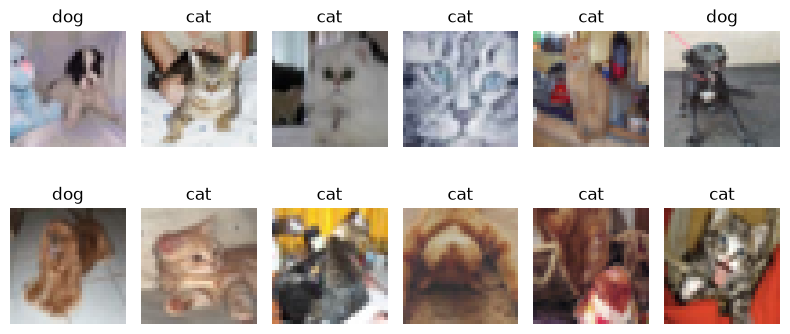

In [8]:
plt.figure(figsize=(8, 4))
for i in range(12):
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_train[i].astype('uint8'))
    label = class_names[CLASS_1] if y_train[i] == 1 else class_names[CLASS_0]
    plt.title(label)
    plt.axis('off')
plt.tight_layout()


## Baseline: training a CNN from scratch

A useful comparison is to train a small CNN from scratch. This model starts with random weights, so all convolutional filters must be learned only from our small training subset.


In [9]:
def build_scratch_cnn():
    model = Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Rescaling(1.0 / 255),
        layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, kernel_size=3, activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

scratch_model = build_scratch_cnn()
scratch_model.summary()
print_parameter_summary(scratch_model, 'Scratch CNN')


I0000 00:00:1782343735.634687   42738 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6123 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

Scratch CNN trainable parameters:     101,569
Scratch CNN non-trainable parameters: 0
Scratch CNN total parameters:         101,569


The model is compiled for binary classification. We use early stopping so that the practical remains manageable and the model does not continue training once validation performance stops improving.


In [10]:
scratch_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

def make_early_stopping():
    return EarlyStopping(
        monitor='val_loss',
        patience=2,
        restore_best_weights=True
    )


The number of epochs is deliberately small. The purpose is not to maximise accuracy, but to create a baseline that can be compared with transfer learning.


In [11]:
EPOCHS_SCRATCH = 3
BATCH_SIZE = 32

history_scratch = scratch_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_SCRATCH,
    validation_split=0.2,
    callbacks=[make_early_stopping()],
    verbose=1
)


Epoch 1/3


I0000 00:00:1782343756.883941   46413 service.cc:153] XLA service 0x77c48c004c50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782343756.883958   46413 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.2)
I0000 00:00:1782343756.920826   46413 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782343757.132761   46413 cuda_dnn.cc:461] Loaded cuDNN version 92302
I0000 00:00:1782343757.167209   46413 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2021__.28
I0000 00:00:1782343757.206974   46413 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set i

31/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4774 - loss: 0.6955

I0000 00:00:1782343761.782067   46413 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.4913 - loss: 0.6939 - val_accuracy: 0.5200 - val_loss: 0.6931
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4963 - loss: 0.6937 - val_accuracy: 0.5475 - val_loss: 0.6930
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5069 - loss: 0.6933 - val_accuracy: 0.4875 - val_loss: 0.6931


The learning curves show whether the model was still improving and whether it started to overfit. With a small dataset, the validation curve can be noisy.


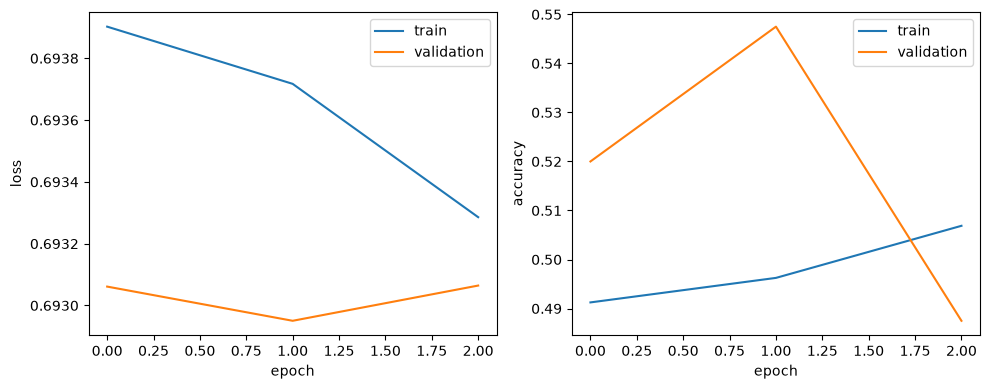

In [12]:
plot_history(history_scratch)


The test set gives an out-of-sample estimate of how the scratch CNN performs on images it did not see during training.


In [13]:
scratch_test_loss, scratch_test_acc = scratch_model.evaluate(X_test, y_test, verbose=0)
print(f'Scratch CNN test loss:     {scratch_test_loss:.4f}')
print(f'Scratch CNN test accuracy: {scratch_test_acc:.4f}')


I0000 00:00:1782343797.062695   46412 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


Scratch CNN test loss:     0.6930
Scratch CNN test accuracy: 0.5520


## Loading a pre-trained CNN

A pre-trained model has already learned filters from a large source dataset. ImageNet-trained CNNs typically learn low-level features such as edges and textures in early layers, and more task-specific features in deeper layers.

We load MobileNetV2 without its original classification head using `include_top=False`. This gives us the convolutional feature extractor, but not the ImageNet output layer.

The first time this cell is run, Keras may need to download the ImageNet weights. If the download fails, the notebook falls back to random weights so the code structure can still be demonstrated, but that fallback is no longer true transfer learning.


In [14]:
IMG_SIZE = 96

try:
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    USING_IMAGENET_WEIGHTS = True
    print('Loaded MobileNetV2 with ImageNet weights.')
except Exception as error:
    print('ImageNet weights could not be loaded.')
    print('The notebook will continue with random weights, but this is not true transfer learning.')
    print('Error:', error)
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights=None
    )
    USING_IMAGENET_WEIGHTS = False

base_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Loaded MobileNetV2 with ImageNet weights.


Model: "mobilenetv2_1.00_96"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

The convolutional base is now frozen. Freezing means that the pre-trained convolutional filters will be used to extract features, but their weights will not be changed during the first stage of training.


In [15]:
base_model.trainable = False

print_parameter_summary(base_model, 'Frozen MobileNetV2 base')
print('Number of trainable weights in the base model:', len(base_model.trainable_weights))


Frozen MobileNetV2 base trainable parameters:     0
Frozen MobileNetV2 base non-trainable parameters: 2,257,984
Frozen MobileNetV2 base total parameters:         2,257,984
Number of trainable weights in the base model: 0


The first few layers confirm that the convolutional base is non-trainable. The same principle applies to all layers in the frozen base.


In [16]:
for layer in base_model.layers[:10]:
    print(f'{layer.name:35s} trainable = {layer.trainable}')


input_layer_1                       trainable = False
Conv1                               trainable = False
bn_Conv1                            trainable = False
Conv1_relu                          trainable = False
expanded_conv_depthwise             trainable = False
expanded_conv_depthwise_BN          trainable = False
expanded_conv_depthwise_relu        trainable = False
expanded_conv_project               trainable = False
expanded_conv_project_BN            trainable = False
block_1_expand                      trainable = False


## Building the transfer-learning model

The new model has three parts:

1. A small preprocessing stage that resizes CIFAR-10 images to the input size expected by MobileNetV2.
2. The frozen pre-trained convolutional base.
3. A new classifier head trained specifically for the cat-versus-dog task.

Only the new classifier head is trainable at this stage.


In [17]:
def build_transfer_model(base_model):
    inputs = layers.Input(shape=(32, 32, 3))
    x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)
    x = layers.Lambda(preprocess_input, name='mobilenetv2_preprocessing')(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='transfer_learning_model')
    return model

transfer_model = build_transfer_model(base_model)
transfer_model.summary()
print_parameter_summary(transfer_model, 'Transfer-learning model')


Model: "transfer_learning_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_preprocessing       │ (None, 96, 96, 3)      │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Transfer-learning model trainable parameters:     1,281
Transfer-learning model non-trainable parameters: 2,257,984
Transfer-learning model total parameters:         2,259,265


The transfer-learning model is compiled in the same way as the scratch model. At this point, optimisation updates only the new dense classifier head; the MobileNetV2 filters stay fixed.


In [18]:
transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


Training the classifier head is usually much faster than training the entire CNN, because the model is reusing features already learned during pre-training.


In [19]:
EPOCHS_TRANSFER = 3

history_transfer = transfer_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_TRANSFER,
    validation_split=0.2,
    callbacks=[make_early_stopping()],
    verbose=1
)


Epoch 1/3


E0000 00:00:1782343938.141143   46414 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5922 - loss: 0.7373

E0000 00:00:1782343946.780213   46411 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 151ms/step - accuracy: 0.6769 - loss: 0.6164 - val_accuracy: 0.8200 - val_loss: 0.4337
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8081 - loss: 0.4209 - val_accuracy: 0.8350 - val_loss: 0.3771
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8344 - loss: 0.3781 - val_accuracy: 0.8375 - val_loss: 0.3591


These curves describe the behaviour of the new classifier head while the feature extractor remains frozen. If ImageNet weights were available, the transfer-learning model may learn useful decision boundaries with fewer examples than the scratch CNN.


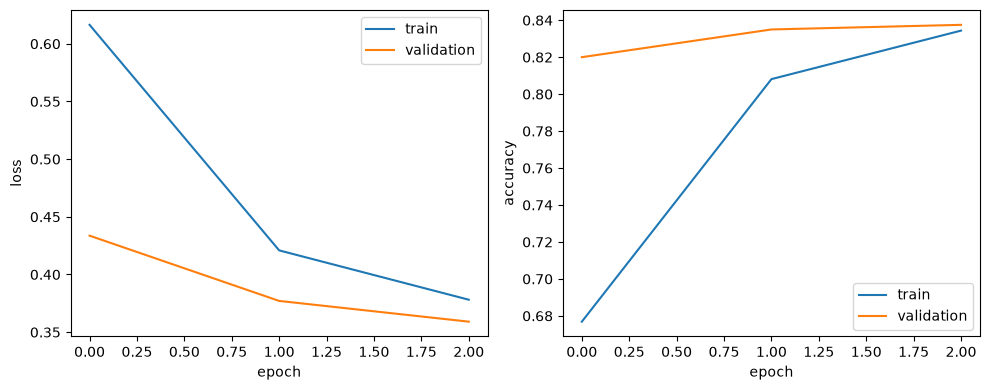

In [20]:
plot_history(history_transfer)


The test-set evaluation allows a direct comparison between the scratch CNN and the transfer-learning model. Exact results will vary between runs, especially because the training subset is intentionally small.


In [21]:
transfer_test_loss, transfer_test_acc = transfer_model.evaluate(X_test, y_test, verbose=0)

results = pd.DataFrame({
    'Model': ['Scratch CNN', 'Frozen MobileNetV2 + new classifier'],
    'Test loss': [scratch_test_loss, transfer_test_loss],
    'Test accuracy': [scratch_test_acc, transfer_test_acc]
})

results


E0000 00:00:1782343964.803806   46412 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


,Model,Test loss,Test accuracy
0,Scratch CNN,0.692955,0.552
1,Frozen MobileNetV2 + new classifier,0.348507,0.862


A few predictions help make the classification task more concrete. The model outputs a probability for class 1, which in this notebook corresponds to dogs.


In [ ]:
probabilities = transfer_model.predict(X_test[:12]).reshape(-1)
predicted_labels = (probabilities >= 0.5).astype(int)

plt.figure(figsize=(9, 5))
for i in range(12):
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_test[i].astype('uint8'))
    true_name = class_names[CLASS_1] if y_test[i] == 1 else class_names[CLASS_0]
    pred_name = class_names[CLASS_1] if predicted_labels[i] == 1 else class_names[CLASS_0]
    plt.title(f'True: {true_name}\nPred: {pred_name}\nP(dog)={probabilities[i]:.2f}', fontsize=9)
    plt.axis('off')
plt.tight_layout()


## Optional fine-tuning

After the new classifier head has learned a reasonable mapping, we can unfreeze a small number of deeper layers in the pre-trained CNN. This is called fine-tuning.

Fine-tuning should be done carefully. If too many layers are unfrozen, or if the learning rate is too high, the model may damage the useful pre-trained features. For this reason, we unfreeze only the last few layers and use a very small learning rate.


In [ ]:
base_model.trainable = True

# Keep most layers frozen and only fine-tune the last few layers.
FINE_TUNE_AT = len(base_model.layers) - 30

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Batch-normalisation layers are usually kept frozen during fine-tuning.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print_parameter_summary(transfer_model, 'Fine-tuning model')
print('Fine-tuning from layer:', FINE_TUNE_AT, '/', len(base_model.layers))


The model must be recompiled after changing which layers are trainable. The learning rate is much smaller than before because the unfrozen layers already contain useful weights.


In [ ]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


The fine-tuning stage is kept very short for the practical session. In a real project, the number of epochs, the number of unfrozen layers, and the learning rate would all be tuned using a validation strategy.


In [ ]:
EPOCHS_FINE_TUNE = 1

history_fine = transfer_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_FINE_TUNE,
    validation_split=0.2,
    callbacks=[make_early_stopping()],
    verbose=1
)


Fine-tuning can sometimes improve performance, but it is not guaranteed. With a small dataset, it can also increase overfitting. The final test-set result should therefore be interpreted together with the validation curves.


In [ ]:
fine_test_loss, fine_test_acc = transfer_model.evaluate(X_test, y_test, verbose=0)

results = pd.DataFrame({
    'Model': [
        'Scratch CNN',
        'Frozen MobileNetV2 + new classifier',
        'Fine-tuned MobileNetV2'
    ],
    'Test loss': [scratch_test_loss, transfer_test_loss, fine_test_loss],
    'Test accuracy': [scratch_test_acc, transfer_test_acc, fine_test_acc]
})

results


## Exercise

Try one or more of the following modifications:

1. Change the two CIFAR-10 classes by editing `CLASS_0` and `CLASS_1`.
2. Increase or decrease `TRAIN_PER_CLASS` and observe how this affects the benefit of transfer learning.
3. Change `FINE_TUNE_AT` so that more or fewer layers are unfrozen.
4. Replace `MobileNetV2` with another Keras application model, such as `ResNet50` or `VGG16`. Remember that larger models will train more slowly and may require more memory.

When reporting your results, compare the scratch model, the frozen feature extractor, and the fine-tuned model. Do not look only at accuracy; also inspect the learning curves for signs of overfitting.


## Summary

This tutorial demonstrated three important ideas:

- **Pre-trained CNN models** can be reused as feature extractors for new tasks.
- **Freezing layers** prevents pre-trained weights from being updated during training.
- **Transfer learning** can reduce the amount of data and training time needed for a new image-classification problem.

The same logic is widely used in applied deep learning: start with a model trained on a large source dataset, replace the task-specific output layers, train the new head, and optionally fine-tune a small part of the base model.
